# Week 7 Day 2

# "THE PRICE IS RIGHT" Capstone Project

This week - fine tune an open-source model!

A model that can estimate how much something costs, from its description.

# Order of play

DAY 1: QLoRA  
DAY 2: Prompt data and Base Model  
DAY 3: Train Part 1  
DAY 4: Train Part 2  
DAY 5: Eval

## First we need to upload the final dataset



In [22]:
import zipfile

zip_path = "/pricer.zip"      # ZIP file
extract_to = "/content/pricer"        # Folder to extract into

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Unzipped successfully!")

✅ Unzipped successfully!


In [23]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from pricer.pricer.items import Item
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt


In [ ]:
LITE_MODE = False

load_dotenv(override=True)
hf_token = "Add your Hugging Face token here"
login(hf_token, add_to_git_credential=True)

In [25]:
username = "AbhishekRavindran"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)
items = train + val + test

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

README.md:   0%|          | 0.00/744 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  243MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.04MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/800000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Loaded 800,000 training items, 10,000 validation items, 10,000 test items


In [27]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

In [28]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

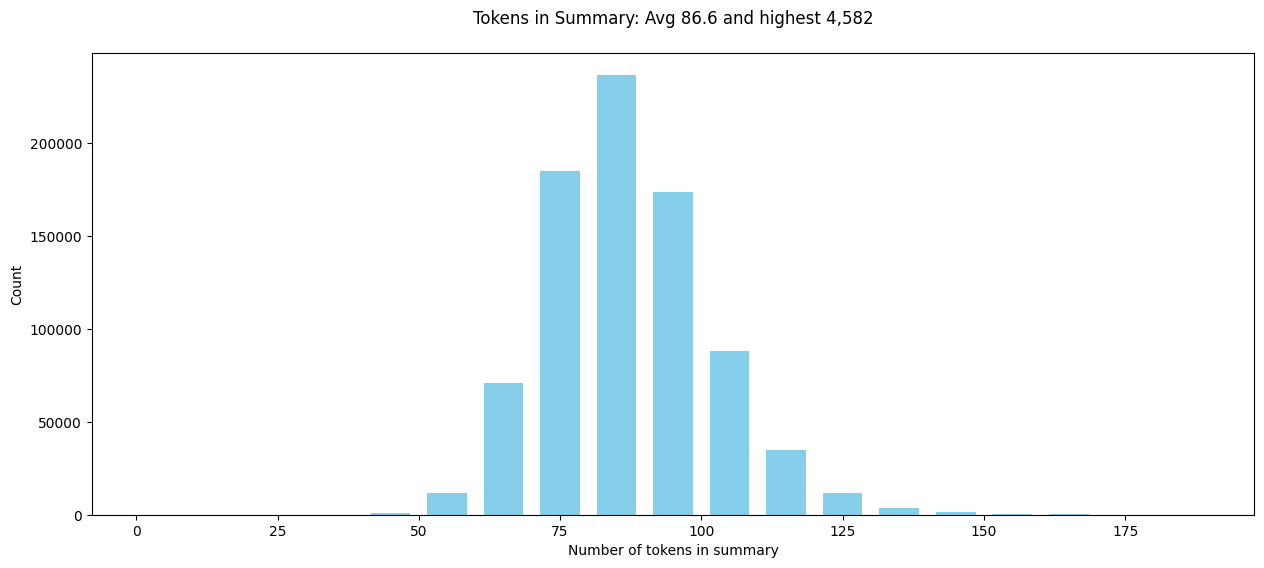

In [29]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 200, 10))
plt.show()

In [30]:
CUTOFF = 110
cut = len([count for count in token_counts if count > CUTOFF])
print(f"With this CUTOFF, we will truncate {cut:,} items which is {cut/len(items):.1%}")


With this CUTOFF, we will truncate 47,083 items which is 5.7%


In [31]:
print(train[0].summary)

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.


In [32]:
for item in tqdm(train+val):
    item.make_prompts(tokenizer, CUTOFF, True)
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, False)

  0%|          | 0/810000 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  0%|          | 0/10000 [00:00<?, ?it/s]

In [33]:
print("PROMPT:")
print(test[0].prompt)
print("COMPLETION:")
print(test[0].completion)


PROMPT:
What does this cost to the nearest dollar?

Title: Excess V2 Distortion/Modulation Pedal  
Category: Music Pedals  
Brand: Old Blood Noise  
Description: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  
Details: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.

Price is $
COMPLETION:
219.0


In [34]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

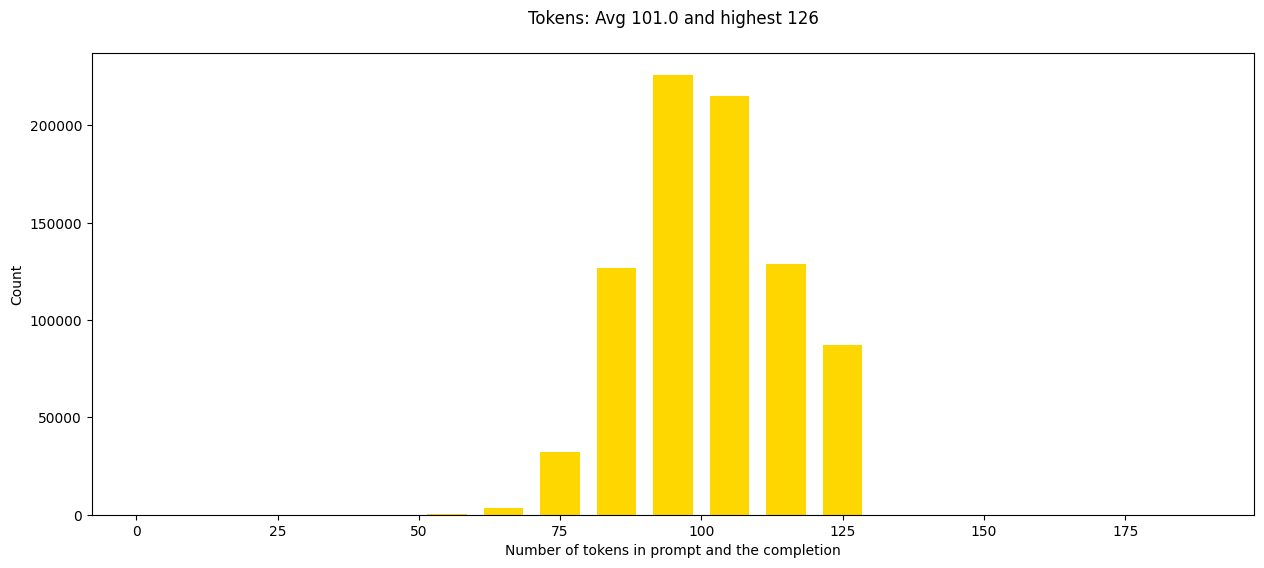

In [35]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="gold", bins=range(0, 200, 10))
plt.show()

In [36]:
from huggingface_hub import whoami

print(whoami())

{'type': 'user', 'id': '6a2ad0d54383dae6577195cf', 'name': 'Rakshhh18904', 'fullname': 'Rakshith V', 'email': 'rakshithv9517@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1788220800, 'isPro': False, 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/no-auth/plPMS4y9BgKqB-mkPAs0D.png', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'My HF Token', 'role': 'write', 'createdAt': '2026-07-25T11:08:04.209Z'}}}


In [19]:
import os

# Disable the new Xet upload backend
os.environ["HF_HUB_DISABLE_XET"] = "1"

In [37]:
username = "Rakshhh18904"
dataset = f"{username}/items_prompts_lite" if LITE_MODE else f"{username}/items_prompts_full"

Item.push_prompts_to_hub(dataset, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/800 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  19%|#9        | 33.2MB /  175MB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|#########9| 2.20MB / 2.21MB            

README.md:   0%|          | 0.00/520 [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


Here are the datasets in HuggingFace:

https://huggingface.co/datasets/AbhishekRavindran/items_prompts_lite

https://huggingface.co/datasets/AbhishekRavindran/items_prompts_full

Please see this notebook in Google Colab:https://colab.research.google.com/drive/18NXaOLvucUpPt91Zo8FftHkssUMuPAEo#scrollTo=uuTX-xonNeOK

else use the below

# The Price is Right

### Week 7 Day 2

Selecting our model and evaluating the base model against the task.

Keep in mind: our base model has 8 billion params, quantized down to 4 bits
Compared with GPT-5 at TRILLIONS of params!

In [38]:
!pip install -q --upgrade bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 20.3 MB/s eta 0:00:00


In [39]:
pip install util

In [40]:
import sys
sys.path.append("/content/pricer/pricer")

In [41]:
# imports

import os
import re
import math
from tqdm import tqdm
from google.colab import userdata
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, set_seed
from peft import LoraConfig, PeftModel
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
import matplotlib.pyplot as plt
from evaluator import evaluate

In [42]:
# Constants

BASE_MODEL = "meta-llama/Llama-3.2-3B"
PROJECT_NAME = "price"

LITE_MODE = True

DATA_USER = "AbhishekRavindran"
DATASET_NAME = f"{DATA_USER}/items_prompts_lite" if LITE_MODE else f"{DATA_USER}/items_prompts_full"

# Hyper-parameters

QUANT_4_BIT = True

### Log in to HuggingFace

If you don't already have a HuggingFace account, visit https://huggingface.co to sign up and create a token.

Then select the Secrets for this Notebook by clicking on the key icon in the left, and add a new secret called `HF_TOKEN` with the value as your token.

In [43]:
# Log in to HuggingFace

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

# Load our data

We uploaded it to Hugging Face, so it's easy to retrieve it now

In [44]:
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
val = dataset['val']
test = dataset['test']

README.md:   0%|          | 0.00/509 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 4.31MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/val-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  216kB            

data/val-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  218kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [45]:
train[0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  \nCategory: Home Hardware  \nBrand: Schlage  \nDescription: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  \nDetails: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.\n\nPrice is $',
 'completion': '64.00'}

# Prepare our Base Llama Model for evaluation

Load our base model with 4 bit quantization and try out 1 example

In [46]:
## pick the right quantization

if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
  )
else:
  quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16
  )

In [47]:
# Load the Tokenizer and the Model

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id

print(f"Memory footprint: {base_model.get_memory_footprint() / 1e9:.1f} GB")

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Memory footprint: 2.2 GB


In [65]:
def model_predict(item):
    # Works with both dicts and objects
    prompt = item["prompt"] if isinstance(item, dict) else item.prompt

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output_ids = base_model.generate(**inputs, max_new_tokens=8)

    prompt_len = inputs["input_ids"].shape[1]
    output = tokenizer.decode(output_ids[0][prompt_len:], skip_special_tokens=True)

    return output

In [66]:
test[0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $',
 'completion': '219.0'}

In [67]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

Torch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8


In [68]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected.")

Torch: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla T4


In [69]:
import torch
print(torch.__version__)

2.11.0+cu128


In [74]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: Tesla T4


In [75]:
model_predict(test[0])

'249.00 USD. Shipping is$'

In [76]:
print(type(test[0]))
print(test[0])

<class 'dict'>
{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $', 'completion': '219.0'}


In [77]:
print(test[0])

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $', 'completion': '219.0'}


In [80]:
from types import SimpleNamespace

test_for_eval = [
    SimpleNamespace(
        prompt=item["prompt"],
        price=float(item["completion"]),
        title=item["prompt"].split("\n")[2].replace("Title: ", "")  # Extract title from prompt
    )
    for item in test
]

# Evaluation!

Trying out our base Llama 3.2 model against the Test dataset

In [81]:
evaluate(model_predict, test_for_eval)

  0%|          | 0/200 [00:00<?, ?it/s]

$19 $116 $29 $80 $129 $210 $121 $175 $11 $80 $213 $321 $7 $34 $29 $20 $29 $45 $90 $79 $120 $76 $70 $75 $319 $363 $1405 $4 $81 $70 $100 $34 $120 $20 $15 $219 $45 $39 $54 $28 $195 $72 $34 $205 $208 $15 $1 $19 $25 $152 $19 $121 $365 $80 $547 $127 $13 $23 $77 $7 $140 $22 $89 $10 $529 $10 $240 $255 $25 $26 $6 $2 $180 $4 $40 $32 $1076 $0 $6 $13 $60 $2 $4 $87 $3 $11 $87 $27 $40 $38 $18 $59 $10 $28 $2 $178 $26 $130 $254 $325 $80 $111 $31 $161 $224 $682 $21 $385 $22 $201 $60 $1686 $68 $68 $96 $280 $3 $10 $26 $78 $8 $611 $20 $136 $1800 $44 $3 $99 $69 $116 $31 $52 $13 $9 $25 $5 $135 $20 $89 $132 $136 $150 $77 $8 $54 $38 $32 $189 $15 $23 $9 $894 $41 $110 $13 $264 $51 $43 $220 $43 $211 $16 $32 $12 $60 $2 $552 $0 $40 $0 $16 $6 $170 $17 $52 $19 $12 $53 $64 $75 $104 $14 $100 $159 $25 $6 $67 $7 $56 $22 $22 $39 $24 $99 $100 $220 $130 $204 $46 $4 